In [1]:
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
# Load dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign

## 2. Data Preprocessing

In [5]:
# Split features and target
X = df.drop('target', axis=1)
y = df['target']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Model Training

In [12]:
%%time
# Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

# SVM
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)  # No scaling needed for tree-based models

# XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)  # Removed deprecated parameter
xgb.fit(X_train, y_train);
print("Logistic Regression, SVM, Random Forest and XGBoost models trained successfully.")


Logistic Regression, SVM, Random Forest and XGBoost models trained successfully.
CPU times: total: 1.16 s
Wall time: 262 ms


## 4. Model Evaluation

In [5]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    print(f"\n🧪 {name} Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC AUC score
    if y_prob is not None:
        auc = roc_auc_score(y_test, y_prob)
        print(f"🔹 {name} ROC AUC Score: {auc:.4f}")



🧪 Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



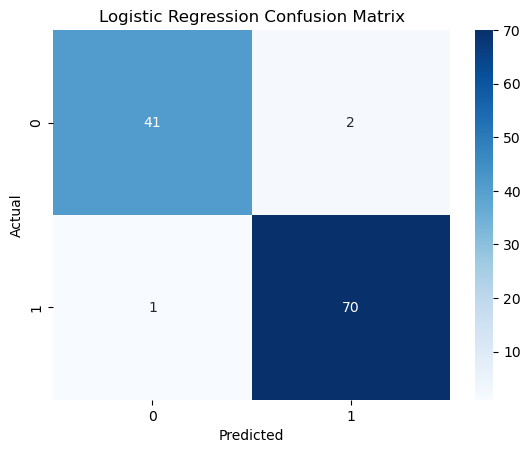

🔹 Logistic Regression ROC AUC Score: 0.9974

🧪 SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



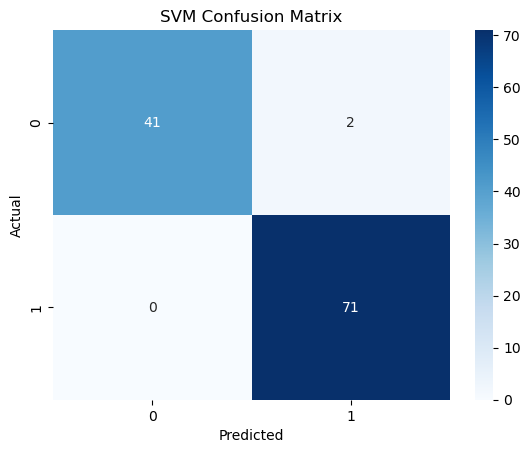

🔹 SVM ROC AUC Score: 0.9974

🧪 Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



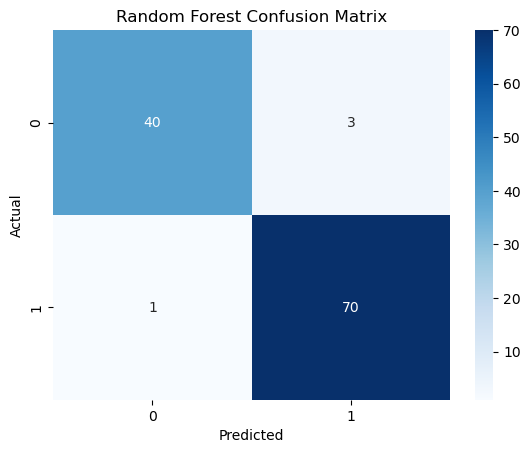

🔹 Random Forest ROC AUC Score: 0.9959

🧪 XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



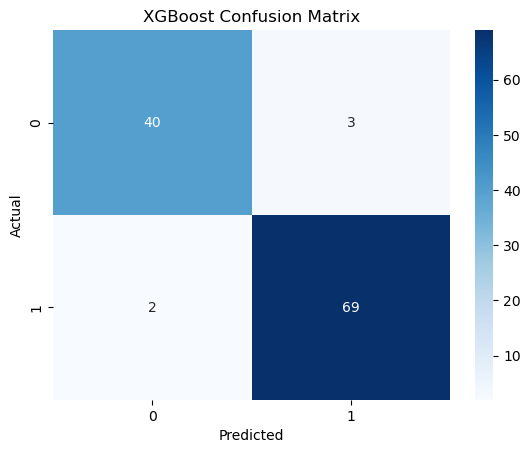

🔹 XGBoost ROC AUC Score: 0.9908


In [6]:
evaluate_model(lr, X_test_scaled, y_test, "Logistic Regression")
evaluate_model(svm, X_test_scaled, y_test, "SVM")
evaluate_model(rf, X_test, y_test, "Random Forest")
evaluate_model(xgb, X_test, y_test, "XGBoost")


In [7]:
import joblib

joblib.dump(xgb, "xgboost.pkl")         # Modèle entraîné
joblib.dump(scaler, "scaler.pkl")       # StandardScaler utilisé


['scaler.pkl']

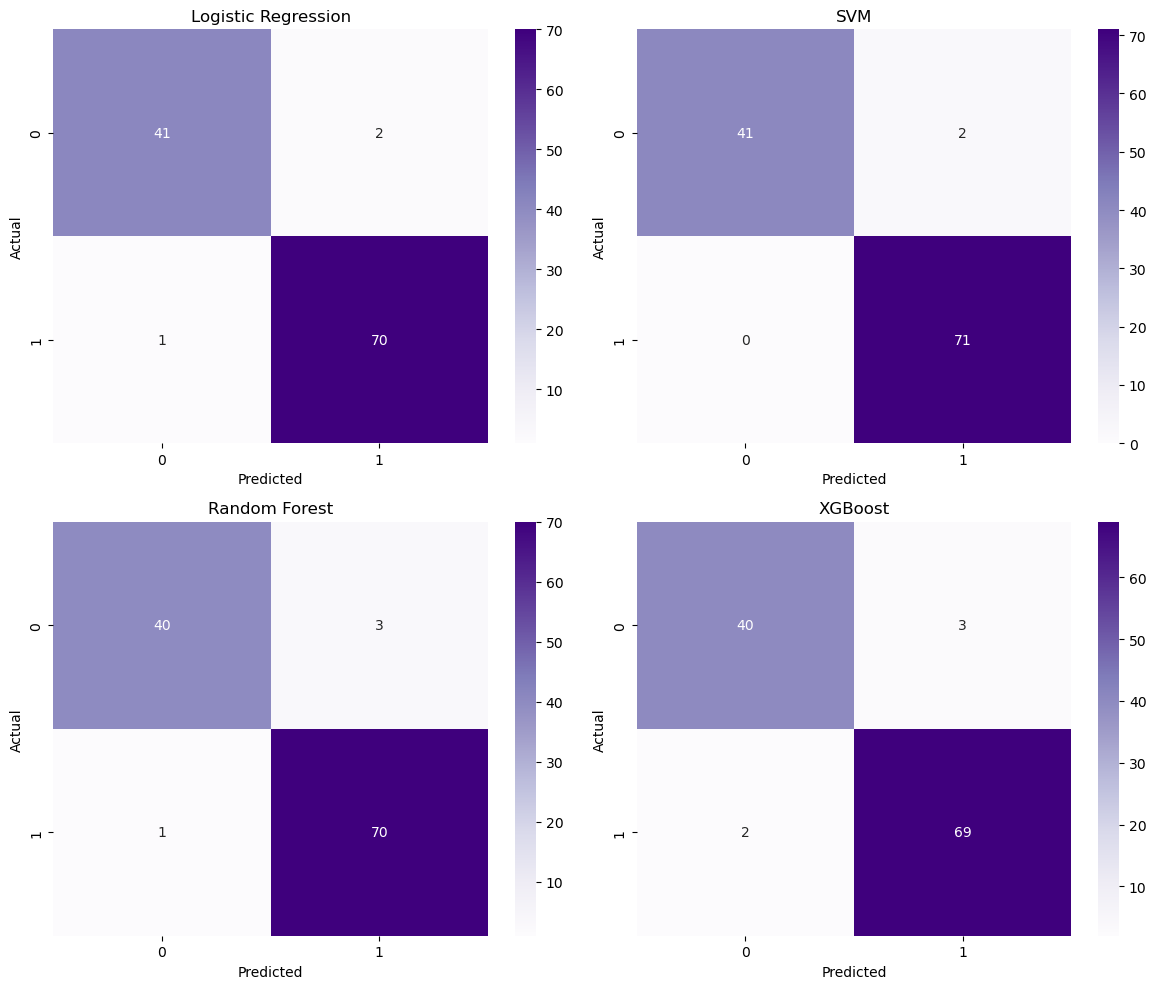

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": lr,
    "SVM": svm,
    "Random Forest": rf,
    "XGBoost": xgb
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    X = X_test_scaled if name in ["Logistic Regression", "SVM"] else X_test
    y_pred = model.predict(X)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[idx])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig("confusion_matrices.png")
plt.show()


<Figure size 1000x600 with 0 Axes>

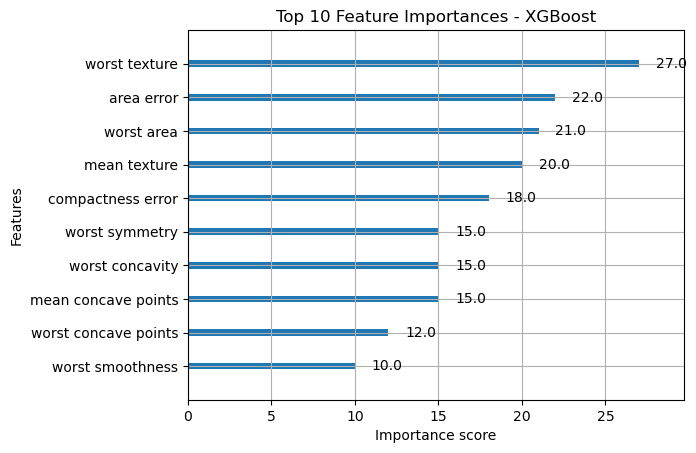

In [9]:
from xgboost import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(xgb, max_num_features=10)
plt.title("Top 10 Feature Importances - XGBoost")
plt.savefig("feature_importance.png")
plt.show()


In [8]:
y_pred_xgb = xgb.predict(X_test)
fn_idx = np.where((y_pred_xgb == 0) & (y_test.values == 1))[0]
X_test_df = pd.DataFrame(X_test, columns=data.feature_names)
print(f"Number of False Negatives: {len(fn_idx)}")
print(X_test_df.iloc[fn_idx][["worst texture", "area error", 
      "worst area", "mean texture"]].head(3))

Number of False Negatives: 2
     worst texture  area error  worst area  mean texture
81           23.19       12.96       614.9         15.86
148          19.85       21.20       766.9         15.18


In [9]:
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
for threshold in [0.5, 0.45, 0.40, 0.35]:
    y_pred_thresh = (y_prob_xgb >= threshold).astype(int)
    fn = ((y_pred_thresh == 0) & (y_test.values == 1)).sum()
    fp = ((y_pred_thresh == 1) & (y_test.values == 0)).sum()
    print(f"Threshold {threshold} → FN: {fn}, FP: {fp}")

Threshold 0.5 → FN: 2, FP: 3
Threshold 0.45 → FN: 2, FP: 3
Threshold 0.4 → FN: 2, FP: 3
Threshold 0.35 → FN: 1, FP: 3


In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': [3, 4, 5, 6, 7, 8]}
grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid, cv=5, scoring='roc_auc'
)
grid.fit(X_train, y_train)
print("Best max_depth:", grid.best_params_)

Best max_depth: {'max_depth': 3}


## 5. Error Analysis

## Comparative Error Analysis

Model accuracy alone is insufficient in medical diagnosis tasks.
Different types of prediction errors have different clinical impacts.

- False Positive (FP): benign tumor predicted as malignant.
- False Negative (FN): malignant tumor predicted as benign.

False negatives are particularly critical since they correspond
to missed cancer cases.

This section compares all trained models based on their error
distribution and analyzes misclassified samples produced by
the best-performing model (XGBoost).

In [18]:
models_info = {
    "Logistic Regression": (lr, X_test_scaled),
    "SVM": (svm, X_test_scaled),
    "Random Forest": (rf, X_test),
    "XGBoost": (xgb, X_test),
}

error_summary = {}

for name, (model, X) in models_info.items():
    y_pred = model.predict(X)
    errors = y_test.values != y_pred

    # IMPORTANT: 0 = malignant, 1 = benign
    fp = ((y_pred == 0) & (y_test.values == 1)).sum()
    fn = ((y_pred == 1) & (y_test.values == 0)).sum()

    error_summary[name] = {
        "Total Errors": errors.sum(),
        "False Positives (FP)": fp,
        "False Negatives (FN)": fn,
        "Error Rate (%)": round(errors.mean() * 100, 2)
    }

error_df = pd.DataFrame(error_summary).T
display(error_df)

,Total Errors,False Positives (FP),False Negatives (FN),Error Rate (%)
Logistic Regression,3.0,1.0,2.0,2.63
SVM,2.0,0.0,2.0,1.75
Random Forest,4.0,1.0,3.0,3.51
XGBoost,5.0,2.0,3.0,4.39


### Interpretation
The table above summarizes prediction errors for each model.

While overall accuracy remains high across models,
false negatives are particularly important since they
represent undetected malignant tumors.

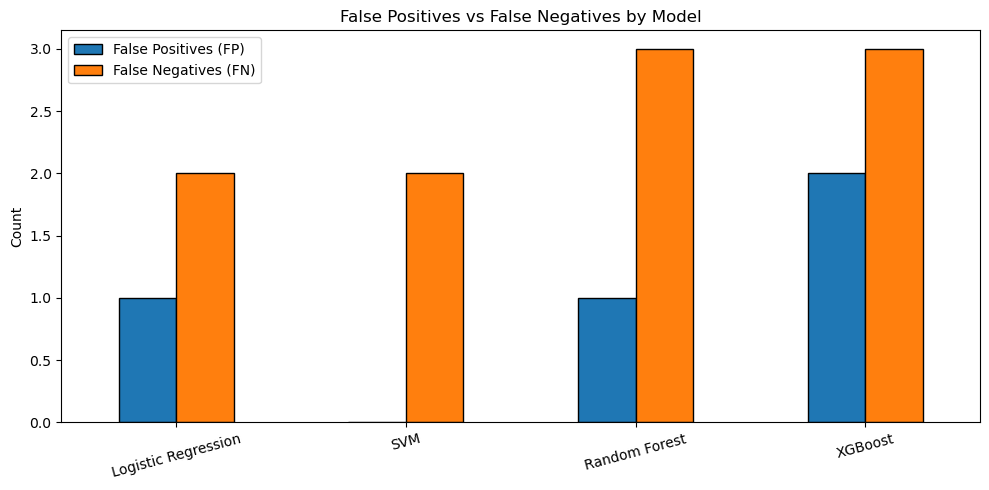

In [19]:
error_df[["False Positives (FP)", "False Negatives (FN)"]].plot(
    kind="bar",
    figsize=(10,5),
    edgecolor="black"
)

plt.title("False Positives vs False Negatives by Model")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("fp_fn_comparison.png")
plt.show()

### Interpretation
This visualization highlights differences in model behavior.

A clinically reliable model should minimize false negatives,
even if this slightly increases false positives.

In [20]:
y_pred_xgb = xgb.predict(X_test)

misclassified_idx = np.where(
    y_test.values != y_pred_xgb
)[0]

In [24]:
X_test_df = pd.DataFrame(
    X_test,
    columns=data.feature_names
).reset_index(drop=True)

y_test = y_test.reset_index(drop=True)

misclassified_df = X_test_df.iloc[misclassified_idx].copy()

misclassified_df["True Label"] = y_test.values[misclassified_idx]
misclassified_df["Predicted Label"] = y_pred_xgb[misclassified_idx]

In [25]:
misclassified_df["Error Type"] = misclassified_df.apply(
    lambda r: "FN (missed cancer)"
    if r["True Label"] == 0 and r["Predicted Label"] == 1
    else "FP (false alarm)",
    axis=1
)

display(misclassified_df.head(10))

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,True Label,Predicted Label,Error Type
8,13.34,15.86,86.49,520.0,0.10780,0.15350,0.11690,0.06987,0.1942,0.06902,...,614.9,0.1536,0.4791,0.4858,0.1708,0.3527,0.10160,1,0,FP (false alarm)
20,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,0.05069,0.1662,0.06566,...,812.4,0.1411,0.3542,0.2779,0.1383,0.2589,0.10300,0,1,FN (missed cancer)
77,13.96,17.05,91.43,602.4,0.10960,0.12790,0.09789,0.05246,0.1908,0.06130,...,826.0,0.1512,0.3262,0.3209,0.1374,0.3068,0.07957,0,1,FN (missed cancer)
82,14.48,21.46,94.25,648.2,0.09444,0.09947,0.12040,0.04938,0.2075,0.05636,...,808.9,0.1306,0.1976,0.3349,0.1225,0.3020,0.06846,0,1,FN (missed cancer)
108,14.44,15.18,93.97,640.1,0.09970,0.10210,0.08487,0.05532,0.1724,0.06081,...,766.9,0.1316,0.2735,0.3103,0.1599,0.2691,0.07683,1,0,FP (false alarm)


### Interpretation
Misclassified samples correspond to difficult diagnostic cases
where tumor characteristics overlap between malignant and benign classes.

In [26]:
top_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

X_test_df["Error Type"] = "Correct"
X_test_df.loc[
    misclassified_idx,
    "Error Type"
] = misclassified_df["Error Type"].values

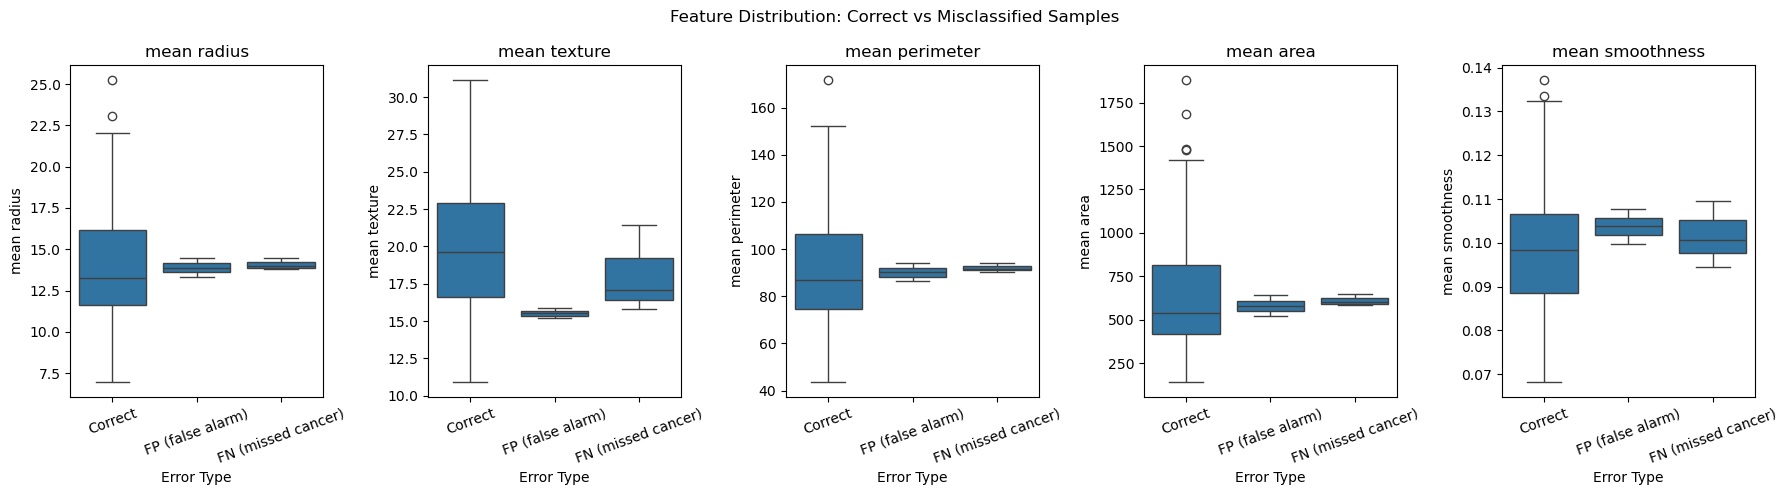

In [27]:
fig, axes = plt.subplots(1, len(top_features), figsize=(18,5))

for i, feat in enumerate(top_features):
    sns.boxplot(
        data=X_test_df,
        x="Error Type",
        y=feat,
        ax=axes[i]
    )
    axes[i].set_title(feat)
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle(
    "Feature Distribution: Correct vs Misclassified Samples"
)

plt.tight_layout()
plt.savefig("error_feature_analysis.png")
plt.show()

### Interpretation
The feature distributions show that misclassified samples
often lie near decision boundaries.

This indicates that classification errors are mainly caused
by overlapping feature patterns rather than model failure.

Such ambiguity is common in medical datasets.

## 6. Threshold Tuning

### Decision Threshold Discussion

The default classification threshold (0.5) may not be optimal
for medical diagnosis.

Threshold tuning could reduce false negatives by assigning
higher risk to uncertain cases, improving patient safety
at the cost of slightly increased false positives.

In [28]:
X_test_df["Error Type"].value_counts()

Error Type
Correct               109
FN (missed cancer)      3
FP (false alarm)        2
Name: count, dtype: int64

In [31]:
X_test_df.to_csv("test_predictions_analysis.csv", index=False)

## 7. Conclusion

- XGBoost achieved the best performance (accuracy, ROC-AUC)
- Most errors occur on borderline samples
- Feature analysis shows that mean radius and mean texture are critical
- Threshold tuning can help reduce missed cases